# Full analysis and summary plots

This notebook runs the analysis scripts when their expected outputs are missing, then builds combined summary figures from the generated tables. It does not read or display any previously saved image files.

In [1]:
from pathlib import Path
import ast
import subprocess
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

REPO_ROOT = Path.cwd()
if REPO_ROOT.name == "notebooks":
    REPO_ROOT = REPO_ROOT.parent
elif not (REPO_ROOT / "configs" / "config.yaml").exists() and (
    REPO_ROOT.parent / "configs" / "config.yaml"
).exists():
    REPO_ROOT = REPO_ROOT.parent

NOTEBOOK_DIR = REPO_ROOT / "notebooks"
for path in (REPO_ROOT, NOTEBOOK_DIR):
    path_str = str(path)
    if path_str not in sys.path:
        sys.path.insert(0, path_str)

import nb_utils
from ngmd import plotting, utils
from ngmd.config import get_config_section, load_config

%matplotlib inline
%reload_ext autoreload
%autoreload 2

warnings.simplefilter(action="ignore", category=FutureWarning)

CONFIG_PATH = REPO_ROOT / "configs" / "config.yaml"
CONFIG = load_config(CONFIG_PATH)
DATA_DIR = Path(CONFIG["paths"]["data_dir"])
ANALYSIS_DIR = DATA_DIR / "analysis_files"
SUMMARY_PLOT_DIR = ANALYSIS_DIR / "summary_plots"
ANALYSIS_DIR.mkdir(parents=True, exist_ok=True)
SUMMARY_PLOT_DIR.mkdir(parents=True, exist_ok=True)

PALETTE = plotting.UnibasColors()
DEV_STAGE_CUTS = utils.get_default_dev_stage_cuts()
DEV_STAGE_LABELS = nb_utils.labels_from_cuts(DEV_STAGE_CUTS)

print(f"Repository: {REPO_ROOT}")
print(f"Dataset: {DATA_DIR}")
print(f"Analysis files: {ANALYSIS_DIR}")
print(f"Summary plots: {SUMMARY_PLOT_DIR}")

Repository: C:\Users\mauls\Documents\Code\neural-graphs-mice-development-main
Dataset: F:\Experiments\Steffen\Intrinsic_Imaging
Analysis files: F:\Experiments\Steffen\Intrinsic_Imaging\analysis_files
Summary plots: F:\Experiments\Steffen\Intrinsic_Imaging\analysis_files\summary_plots


## Analysis execution

The notebook reruns only missing outputs by default. Set `FORCE_ANALYSIS = True` to regenerate existing CSV/GZip analysis files.

In [2]:
RUN_ANALYSIS = True
FORCE_ANALYSIS = False
PRECOMPUTE_STTC_ARRAYS = False
N_SESSIONS_IN_PARALLEL = 1

NETWORK_CONFIG = get_config_section(
    "network_summaries",
    {"num_subsample_trials": 20, "subsample_size": 250},
    config_path=CONFIG_PATH,
)
STRUCTURAL_CONFIG = get_config_section(
    "structural_consistency",
    {"num_trials": 20, "num_subsample_trials": 20, "subsample_size": 250},
    config_path=CONFIG_PATH,
)

NETWORK_SUBSAMPLE_SIZE = NETWORK_CONFIG["subsample_size"]
STRUCTURAL_SUBSAMPLE_SIZE = STRUCTURAL_CONFIG["subsample_size"]

NETWORK_SUMMARY_SPECS = [
    ("zscores", 1),
    ("zscores", 2),
    ("zscores", 4),
    ("zscores", 8),
    ("sttc_percentiles", 95),
    ("sttc_percentiles", 96),
    ("sttc_percentiles", 97),
    ("sttc_percentiles", 98),
    ("sttc_percentiles", 99),
]
DEFAULT_GRAPH_SPECS = CONFIG["notebook_analysis"]["default_graph_specs"]
STRUCTURAL_SPECS = [
    ("zscores", 4),
    ("sttc_percentiles", 95),
    ("sttc_percentiles", 96),
    ("sttc_percentiles", 97),
    ("sttc_percentiles", 98),
]
SIMILARITY_STAT_SPECS = ["corrs", "sttc"]

In [3]:
def fmt_thresh(connect_thresh):
    return f"{float(connect_thresh):.1f}"


def subsample_suffix(subsample_size):
    return "" if subsample_size is None else f"_subsample_size={subsample_size}"


def script_cmd(script_name, *args):
    return [sys.executable, str(REPO_ROOT / "scripts" / "data_generation" / script_name), *map(str, args)]


def network_summary_path(sim_type, connect_thresh):
    name = (
        f"network_summaries_{sim_type}_connect_thresh={fmt_thresh(connect_thresh)}"
        f"{subsample_suffix(NETWORK_SUBSAMPLE_SIZE)}.csv"
    )
    return ANALYSIS_DIR / name


def structural_consistency_path(sim_type, connect_thresh):
    name = (
        f"structural_consistency_{sim_type}_connect_thresh={fmt_thresh(connect_thresh)}"
        f"{subsample_suffix(STRUCTURAL_SUBSAMPLE_SIZE)}.csv"
    )
    return ANALYSIS_DIR / name


def degree_distribution_path(sim_type, connect_thresh):
    return ANALYSIS_DIR / f"degree_distributions_{sim_type}_connect_thresh={fmt_thresh(connect_thresh)}.csv"


def laplacian_spectra_path(sim_type, connect_thresh):
    return ANALYSIS_DIR / f"laplacian_spectra_{sim_type}_connect_thresh={fmt_thresh(connect_thresh)}.csv"


def small_worldness_path(sim_type, connect_thresh):
    return ANALYSIS_DIR / f"small_worldness_{sim_type}_connect_thresh={fmt_thresh(connect_thresh)}.csv"


def output_is_ready(outputs):
    return all(Path(output).exists() for output in outputs)


def run_job(label, cmd, outputs):
    outputs = [Path(output) for output in outputs]
    if outputs and output_is_ready(outputs) and not FORCE_ANALYSIS:
        return {"analysis": label, "status": "skipped", "outputs": ", ".join(p.name for p in outputs)}

    print(f"Running {label}...")
    subprocess.run(cmd, cwd=REPO_ROOT, check=True)
    return {"analysis": label, "status": "ran", "outputs": ", ".join(p.name for p in outputs)}


analysis_jobs = [
    (
        "binarized trace statistics",
        script_cmd("binarized_traces_statistics.py", "--data_dir", DATA_DIR, "--save_dir", ANALYSIS_DIR),
        [ANALYSIS_DIR / "pulse_rates.gz", ANALYSIS_DIR / "pulse_widths.gz", ANALYSIS_DIR / "pulse_intervals.gz"],
    )
]

for sim_type in SIMILARITY_STAT_SPECS:
    analysis_jobs.append(
        (
            f"similarity matrix statistics ({sim_type})",
            script_cmd("sim_mat_statistics.py", "--data_dir", DATA_DIR, "--save_dir", ANALYSIS_DIR, "--sim_type", sim_type),
            [ANALYSIS_DIR / f"{sim_type}_statistics.csv"],
        )
    )

for sim_type, connect_thresh in DEFAULT_GRAPH_SPECS:
    analysis_jobs.extend(
        [
            (
                f"degree distributions ({sim_type}, {connect_thresh})",
                script_cmd(
                    "degree_distributions.py",
                    "--data_dir",
                    DATA_DIR,
                    "--save_dir",
                    ANALYSIS_DIR,
                    "--sim_type",
                    sim_type,
                    "--connect_thresh",
                    connect_thresh,
                ),
                [degree_distribution_path(sim_type, connect_thresh)],
            ),
            (
                f"laplacian spectra ({sim_type}, {connect_thresh})",
                script_cmd(
                    "laplacian_spectra.py",
                    "--data_dir",
                    DATA_DIR,
                    "--save_dir",
                    ANALYSIS_DIR,
                    "--sim_type",
                    sim_type,
                    "--connect_thresh",
                    connect_thresh,
                ),
                [laplacian_spectra_path(sim_type, connect_thresh)],
            ),
            (
                f"small-worldness ({sim_type}, {connect_thresh})",
                script_cmd(
                    "small_worldness.py",
                    "--data_dir",
                    DATA_DIR,
                    "--save_dir",
                    ANALYSIS_DIR,
                    "--sim_type",
                    sim_type,
                    "--connect_thresh",
                    connect_thresh,
                ),
                [small_worldness_path(sim_type, connect_thresh)],
            ),
        ]
    )

for sim_type, connect_thresh in NETWORK_SUMMARY_SPECS:
    analysis_jobs.append(
        (
            f"network summaries ({sim_type}, {connect_thresh})",
            script_cmd(
                "network_summaries.py",
                "--data_dir",
                DATA_DIR,
                "--save_dir",
                ANALYSIS_DIR,
                "--sim_type",
                sim_type,
                "--connect_thresh",
                connect_thresh,
            ),
            [network_summary_path(sim_type, connect_thresh)],
        )
    )

for sim_type, connect_thresh in STRUCTURAL_SPECS:
    analysis_jobs.append(
        (
            f"structural consistency ({sim_type}, {connect_thresh})",
            script_cmd(
                "structural_consistency.py",
                "--data_dir",
                DATA_DIR,
                "--save_dir",
                ANALYSIS_DIR,
                "--sim_type",
                sim_type,
                "--connect_thresh",
                connect_thresh,
            ),
            [structural_consistency_path(sim_type, connect_thresh)],
        )
    )

In [4]:
run_status = []

if PRECOMPUTE_STTC_ARRAYS:
    subprocess.run(
        script_cmd(
            "precompute_sttc_arrays.py",
            "--data_dir",
            DATA_DIR,
            "--n_sessions_in_parallel",
            N_SESSIONS_IN_PARALLEL,
        ),
        cwd=REPO_ROOT,
        check=True,
    )

if RUN_ANALYSIS:
    for label, cmd, outputs in analysis_jobs:
        run_status.append(run_job(label, cmd, outputs))
else:
    run_status.append({"analysis": "all", "status": "not run", "outputs": ""})

pd.DataFrame(run_status)

,analysis,status,outputs
0,binarized trace statistics,skipped,"pulse_rates.gz, pulse_widths.gz, pulse_interva..."
1,similarity matrix statistics (corrs),skipped,corrs_statistics.csv
2,similarity matrix statistics (sttc),skipped,sttc_statistics.csv
3,"degree distributions (zscores, 4)",skipped,degree_distributions_zscores_connect_thresh=4....
4,"laplacian spectra (zscores, 4)",skipped,laplacian_spectra_zscores_connect_thresh=4.0.csv
5,"small-worldness (zscores, 4)",skipped,small_worldness_zscores_connect_thresh=4.0.csv
6,"degree distributions (sttc_percentiles, 95)",skipped,degree_distributions_sttc_percentiles_connect_...
7,"laplacian spectra (sttc_percentiles, 95)",skipped,laplacian_spectra_sttc_percentiles_connect_thr...
8,"small-worldness (sttc_percentiles, 95)",skipped,small_worldness_sttc_percentiles_connect_thres...
9,"network summaries (zscores, 1)",skipped,network_summaries_zscores_connect_thresh=1.0_s...


## Load generated tables

In [5]:
def read_table(path, **kwargs):
    path = Path(path)
    if not path.exists():
        print(f"Missing: {path}")
        return pd.DataFrame()
    return pd.read_csv(path, **kwargs)


def parse_list_value(value):
    if isinstance(value, str):
        return ast.literal_eval(value)
    return value


def parse_list_columns(df, columns):
    df = df.copy()
    for column in columns:
        if column in df:
            df[column] = df[column].apply(parse_list_value)
    return df


def add_dev_window(df):
    df = df.copy()
    if not df.empty and "dev_stage" in df:
        df["dev_window"] = pd.cut(
            df["dev_stage"],
            bins=DEV_STAGE_CUTS,
            labels=DEV_STAGE_LABELS,
            include_lowest=True,
        )
    return df


def concat_frames(frames):
    frames = [frame for frame in frames if not frame.empty]
    if not frames:
        return pd.DataFrame()
    return pd.concat(frames, ignore_index=True)


def flatten_list_column(df, column):
    if df.empty or column not in df:
        return np.array([])
    values = []
    for item in df[column].dropna():
        values.extend(parse_list_value(item))
    return np.asarray(values, dtype=float)


def boxplot_by_dev(df, column, ax, title=None, ylabel=None, showfliers=False):
    if df.empty or column not in df:
        ax.text(0.5, 0.5, "missing data", ha="center", va="center")
        ax.set_axis_off()
        return ax

    grouped_values = []
    labels = []
    for label in DEV_STAGE_LABELS:
        values = df.loc[df["dev_window"] == label, column].dropna().to_numpy(dtype=float)
        if len(values) > 0:
            grouped_values.append(values)
            labels.append(label)

    if not grouped_values:
        ax.text(0.5, 0.5, "no values", ha="center", va="center")
        ax.set_axis_off()
        return ax

    ax.boxplot(grouped_values, labels=labels, showfliers=showfliers, sym="+")
    ax.set_title(title or column)
    ax.set_ylabel(ylabel or column)
    ax.tick_params(axis="x", labelrotation=45)
    ax.grid(axis="y", color="0.85", linewidth=0.8)
    return ax


def save_summary_fig(fig, file_name):
    fig.tight_layout()
    path = SUMMARY_PLOT_DIR / file_name
    fig.savefig(path, dpi=300, bbox_inches="tight")
    print(f"Saved {path}")
    return path

In [6]:
pulse_rates = add_dev_window(read_table(ANALYSIS_DIR / "pulse_rates.gz", compression="gzip"))
pulse_widths = add_dev_window(read_table(ANALYSIS_DIR / "pulse_widths.gz", compression="gzip"))
pulse_intervals = add_dev_window(read_table(ANALYSIS_DIR / "pulse_intervals.gz", compression="gzip"))

sim_statistics = {
    sim_type: add_dev_window(
        parse_list_columns(read_table(ANALYSIS_DIR / f"{sim_type}_statistics.csv"), ["sim_counts", "sim_bins"])
    )
    for sim_type in SIMILARITY_STAT_SPECS
}

degree_frames = []
for sim_type, connect_thresh in DEFAULT_GRAPH_SPECS:
    df = parse_list_columns(read_table(degree_distribution_path(sim_type, connect_thresh)), ["degrees"])
    if not df.empty:
        df["sim_type"] = sim_type
        df["connect_thresh"] = connect_thresh
        degree_frames.append(add_dev_window(df))
degree_df = concat_frames(degree_frames)

network_frames = []
for sim_type, connect_thresh in NETWORK_SUMMARY_SPECS:
    df = read_table(network_summary_path(sim_type, connect_thresh))
    if not df.empty:
        df["sim_type"] = sim_type
        df["connect_thresh"] = connect_thresh
        if {"size_largest_cc", "num_neurons"}.issubset(df.columns):
            df["rel_size_largest_cc"] = df["size_largest_cc"] / df["num_neurons"]
        network_frames.append(add_dev_window(df))
network_df = concat_frames(network_frames)

small_worldness_frames = []
for sim_type, connect_thresh in DEFAULT_GRAPH_SPECS:
    df = read_table(small_worldness_path(sim_type, connect_thresh))
    if not df.empty:
        df["sim_type"] = sim_type
        df["connect_thresh"] = connect_thresh
        small_worldness_frames.append(df)
small_worldness_df = concat_frames(small_worldness_frames)

if not network_df.empty and not small_worldness_df.empty:
    merge_keys = ["animal_id", "session_date", "dev_stage", "sim_type", "connect_thresh"]
    network_df = network_df.merge(small_worldness_df, on=merge_keys, how="left")

structural_frames = []
for sim_type, connect_thresh in STRUCTURAL_SPECS:
    df = read_table(structural_consistency_path(sim_type, connect_thresh))
    if not df.empty:
        df["sim_type"] = sim_type
        df["connect_thresh"] = connect_thresh
        structural_frames.append(add_dev_window(df))
structural_df = concat_frames(structural_frames)

laplacian_frames = []
for sim_type, connect_thresh in DEFAULT_GRAPH_SPECS:
    df = parse_list_columns(read_table(laplacian_spectra_path(sim_type, connect_thresh)), ["eigenvalues"])
    if not df.empty:
        df["sim_type"] = sim_type
        df["connect_thresh"] = connect_thresh
        laplacian_frames.append(add_dev_window(df))
laplacian_df = concat_frames(laplacian_frames)

pd.DataFrame(
    [
        {"table": "pulse_rates", "rows": len(pulse_rates)},
        {"table": "pulse_widths", "rows": len(pulse_widths)},
        {"table": "pulse_intervals", "rows": len(pulse_intervals)},
        {"table": "degree_df", "rows": len(degree_df)},
        {"table": "network_df", "rows": len(network_df)},
        {"table": "structural_df", "rows": len(structural_df)},
        {"table": "laplacian_df", "rows": len(laplacian_df)},
    ]
)

,table,rows
0,pulse_rates,175738
1,pulse_widths,2782903
2,pulse_intervals,2607165
3,degree_df,1021
4,network_df,2993
5,structural_df,1646
6,laplacian_df,1021


## Binarized trace summaries

C:\Users\mauls\AppData\Local\Temp\ipykernel_56508\641675152.py:70: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(grouped_values, labels=labels, showfliers=showfliers, sym="+")
C:\Users\mauls\AppData\Local\Temp\ipykernel_56508\641675152.py:70: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(grouped_values, labels=labels, showfliers=showfliers, sym="+")


Saved F:\Experiments\Steffen\Intrinsic_Imaging\analysis_files\summary_plots\trace_statistics_summary.png


WindowsPath('F:/Experiments/Steffen/Intrinsic_Imaging/analysis_files/summary_plots/trace_statistics_summary.png')

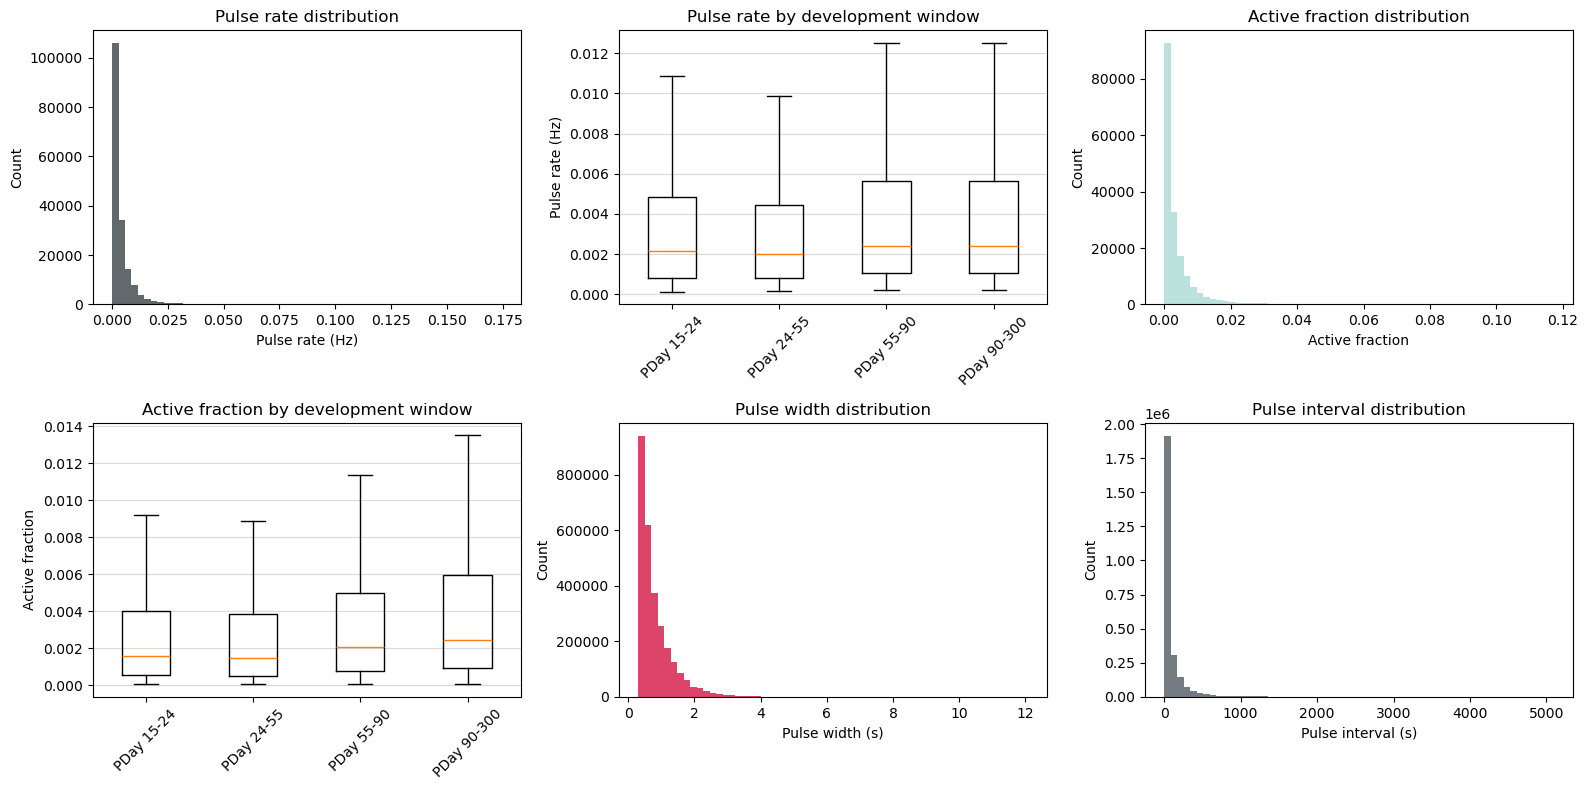

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.ravel()

if not pulse_rates.empty:
    axes[0].hist(pulse_rates["pulse_rate"].dropna(), bins=60, color=PALETTE.anthrazit, alpha=0.75)
    axes[0].set(title="Pulse rate distribution", xlabel="Pulse rate (Hz)", ylabel="Count")
    boxplot_by_dev(pulse_rates, "pulse_rate", axes[1], title="Pulse rate by development window", ylabel="Pulse rate (Hz)")
    axes[2].hist(pulse_rates["active_fraction"].dropna(), bins=60, color=PALETTE.mint, alpha=0.75)
    axes[2].set(title="Active fraction distribution", xlabel="Active fraction", ylabel="Count")
    boxplot_by_dev(pulse_rates, "active_fraction", axes[3], title="Active fraction by development window", ylabel="Active fraction")
else:
    for ax in axes[:4]:
        ax.text(0.5, 0.5, "missing pulse rate data", ha="center", va="center")
        ax.set_axis_off()

if not pulse_widths.empty:
    axes[4].hist(pulse_widths["pulse_widths"].dropna(), bins=60, color=PALETTE.rot, alpha=0.75)
    axes[4].set(title="Pulse width distribution", xlabel="Pulse width (s)", ylabel="Count")
else:
    axes[4].text(0.5, 0.5, "missing pulse width data", ha="center", va="center")
    axes[4].set_axis_off()

if not pulse_intervals.empty:
    axes[5].hist(pulse_intervals["pulse_intervals"].dropna(), bins=60, color=PALETTE.anthrazit_hell, alpha=0.75)
    axes[5].set(title="Pulse interval distribution", xlabel="Pulse interval (s)", ylabel="Count")
else:
    axes[5].text(0.5, 0.5, "missing pulse interval data", ha="center", va="center")
    axes[5].set_axis_off()

save_summary_fig(fig, "trace_statistics_summary.png")

## Similarity matrix summaries

C:\Users\mauls\AppData\Local\Temp\ipykernel_56508\641675152.py:70: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(grouped_values, labels=labels, showfliers=showfliers, sym="+")
C:\Users\mauls\AppData\Local\Temp\ipykernel_56508\641675152.py:70: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(grouped_values, labels=labels, showfliers=showfliers, sym="+")


Saved F:\Experiments\Steffen\Intrinsic_Imaging\analysis_files\summary_plots\similarity_statistics_summary.png


WindowsPath('F:/Experiments/Steffen/Intrinsic_Imaging/analysis_files/summary_plots/similarity_statistics_summary.png')

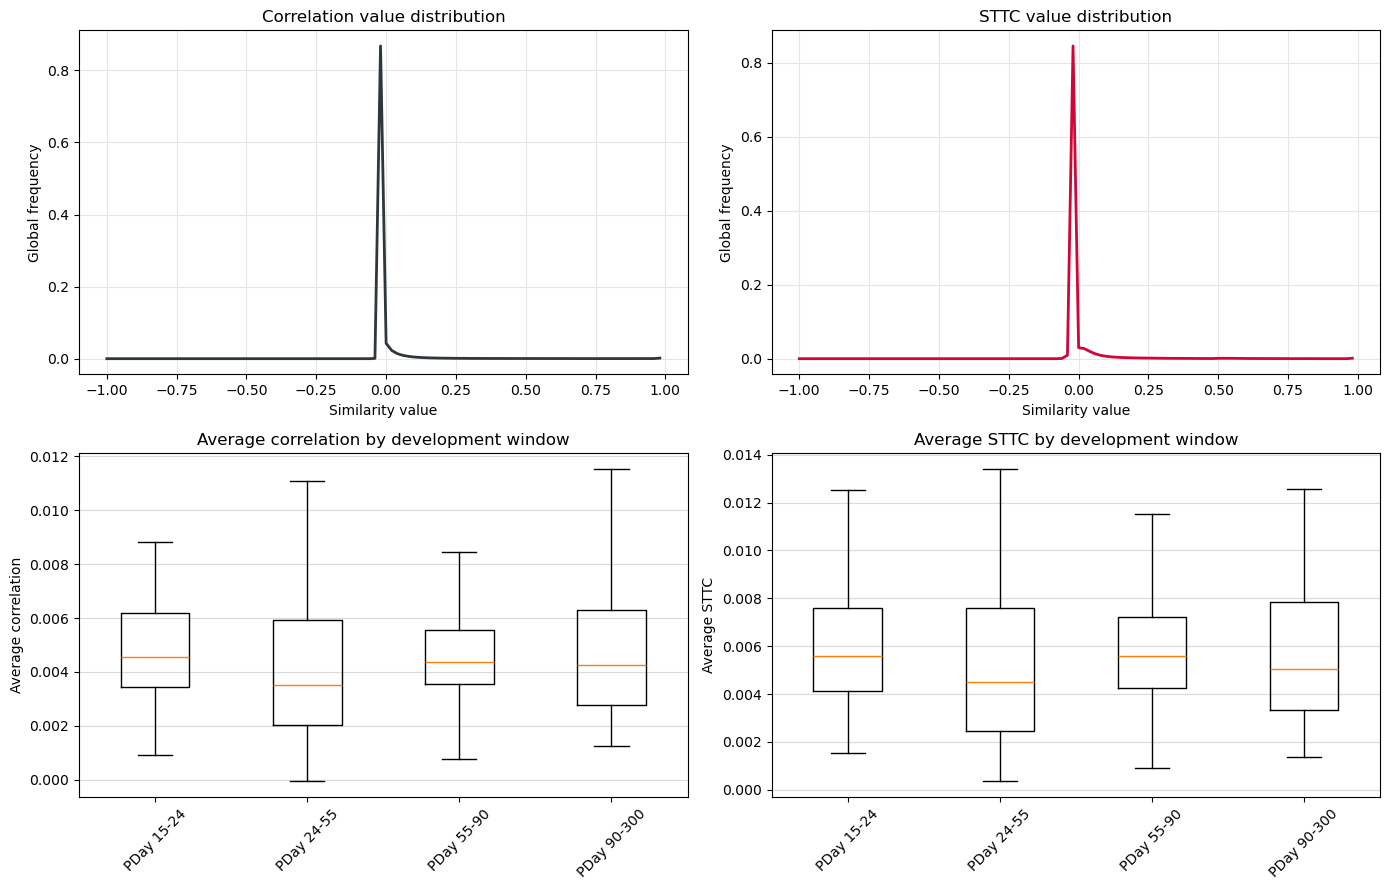

In [8]:
def plot_global_similarity_hist(df, ax, label, color):
    if df.empty:
        ax.text(0.5, 0.5, f"missing {label}", ha="center", va="center")
        ax.set_axis_off()
        return ax

    counts = np.vstack(df["sim_counts"].to_numpy()).sum(axis=0)
    bins = np.asarray(df["sim_bins"].iloc[0], dtype=float)[:-1]
    denom = (df["num_neurons"] * (df["num_neurons"] - 1)).sum()
    ax.plot(bins, counts / denom, color=color, linewidth=2)
    ax.set(title=f"{label} value distribution", xlabel="Similarity value", ylabel="Global frequency")
    ax.grid(color="0.9")
    return ax


fig, axes = plt.subplots(2, 2, figsize=(14, 9))
plot_global_similarity_hist(sim_statistics.get("corrs", pd.DataFrame()), axes[0, 0], "Correlation", PALETTE.anthrazit)
plot_global_similarity_hist(sim_statistics.get("sttc", pd.DataFrame()), axes[0, 1], "STTC", PALETTE.rot)

boxplot_by_dev(
    sim_statistics.get("corrs", pd.DataFrame()),
    "avg_sim_val",
    axes[1, 0],
    title="Average correlation by development window",
    ylabel="Average correlation",
)
boxplot_by_dev(
    sim_statistics.get("sttc", pd.DataFrame()),
    "avg_sim_val",
    axes[1, 1],
    title="Average STTC by development window",
    ylabel="Average STTC",
)

save_summary_fig(fig, "similarity_statistics_summary.png")

## Degree distribution summaries

Saved F:\Experiments\Steffen\Intrinsic_Imaging\analysis_files\summary_plots\degree_distribution_summary.png


WindowsPath('F:/Experiments/Steffen/Intrinsic_Imaging/analysis_files/summary_plots/degree_distribution_summary.png')

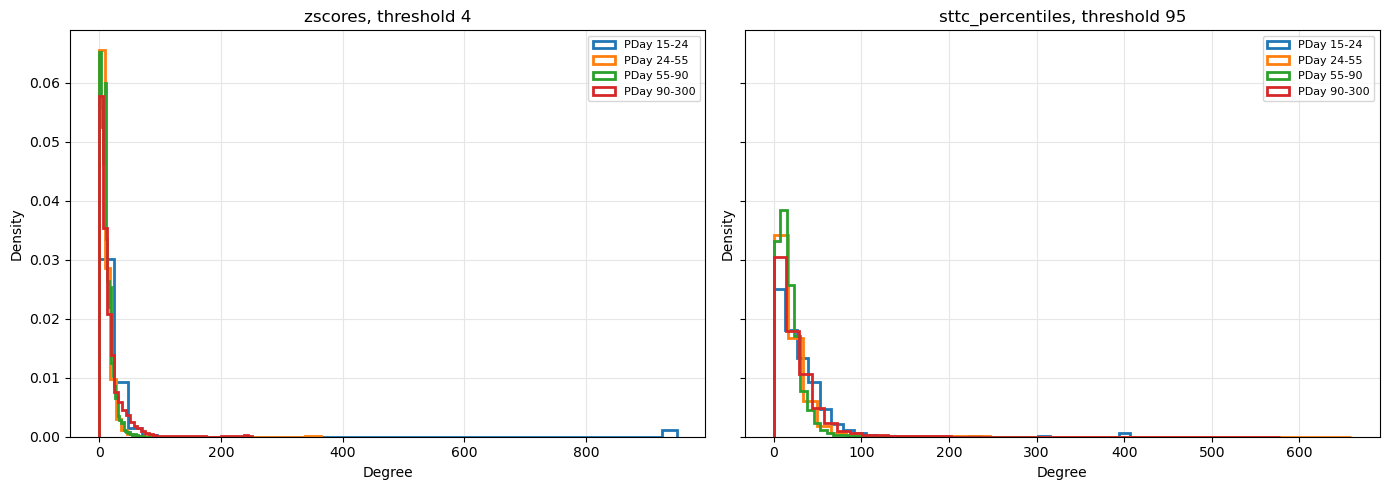

In [9]:
fig, axes = plt.subplots(1, len(DEFAULT_GRAPH_SPECS), figsize=(14, 5), sharey=True)
if len(DEFAULT_GRAPH_SPECS) == 1:
    axes = [axes]

for ax, (sim_type, connect_thresh) in zip(axes, DEFAULT_GRAPH_SPECS):
    selected = degree_df[
        (degree_df.get("sim_type") == sim_type) & (degree_df.get("connect_thresh") == connect_thresh)
    ] if not degree_df.empty else pd.DataFrame()

    if selected.empty:
        ax.text(0.5, 0.5, "missing degree data", ha="center", va="center")
        ax.set_axis_off()
        continue

    for j, label in enumerate(DEV_STAGE_LABELS):
        values = flatten_list_column(selected[selected["dev_window"] == label], "degrees")
        if len(values) == 0:
            continue
        ax.hist(
            values,
            bins=40,
            density=True,
            histtype="step",
            linewidth=2,
            label=label,
            color=plt.cm.tab10(j),
        )

    ax.set_title(f"{sim_type}, threshold {connect_thresh}")
    ax.set_xlabel("Degree")
    ax.set_ylabel("Density")
    ax.grid(color="0.9")
    ax.legend(fontsize=8)

save_summary_fig(fig, "degree_distribution_summary.png")

## Network metric summaries

C:\Users\mauls\AppData\Local\Temp\ipykernel_56508\641675152.py:70: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(grouped_values, labels=labels, showfliers=showfliers, sym="+")
C:\Users\mauls\AppData\Local\Temp\ipykernel_56508\641675152.py:70: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(grouped_values, labels=labels, showfliers=showfliers, sym="+")
C:\Users\mauls\AppData\Local\Temp\ipykernel_56508\641675152.py:70: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(grouped_values, labels=labels, showfliers=showfliers, sym="+")
C:\Users\mauls\AppData\Local\Temp\ipykernel_56508\641675152.py:7

Saved F:\Experiments\Steffen\Intrinsic_Imaging\analysis_files\summary_plots\network_metrics_summary_zscores_4.0.png


C:\Users\mauls\AppData\Local\Temp\ipykernel_56508\641675152.py:70: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(grouped_values, labels=labels, showfliers=showfliers, sym="+")
C:\Users\mauls\AppData\Local\Temp\ipykernel_56508\641675152.py:70: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(grouped_values, labels=labels, showfliers=showfliers, sym="+")
C:\Users\mauls\AppData\Local\Temp\ipykernel_56508\641675152.py:70: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(grouped_values, labels=labels, showfliers=showfliers, sym="+")
C:\Users\mauls\AppData\Local\Temp\ipykernel_56508\641675152.py:7

Saved F:\Experiments\Steffen\Intrinsic_Imaging\analysis_files\summary_plots\network_metrics_summary_sttc_percentiles_95.0.png


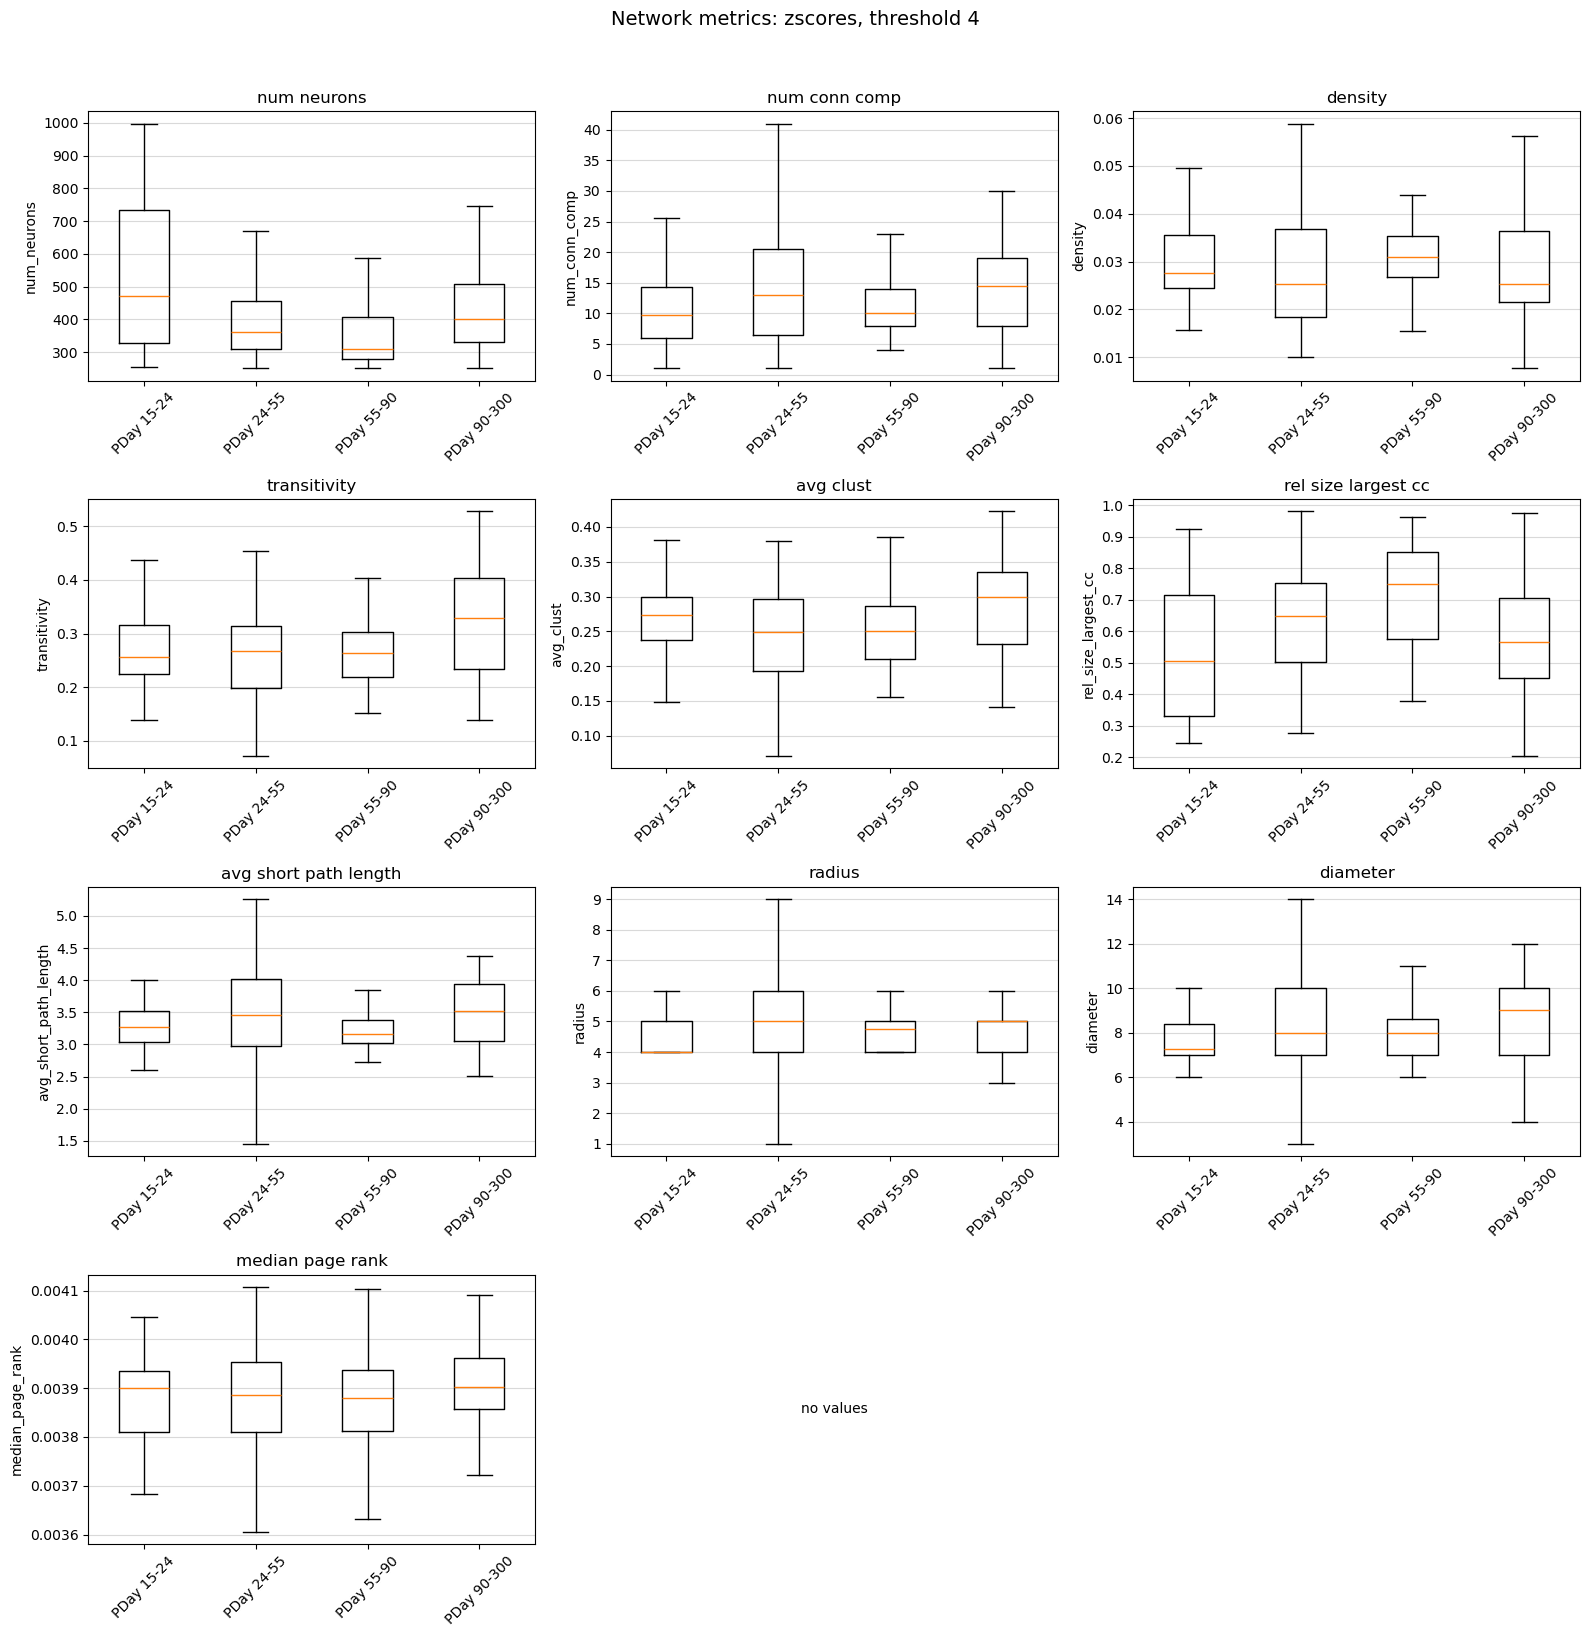

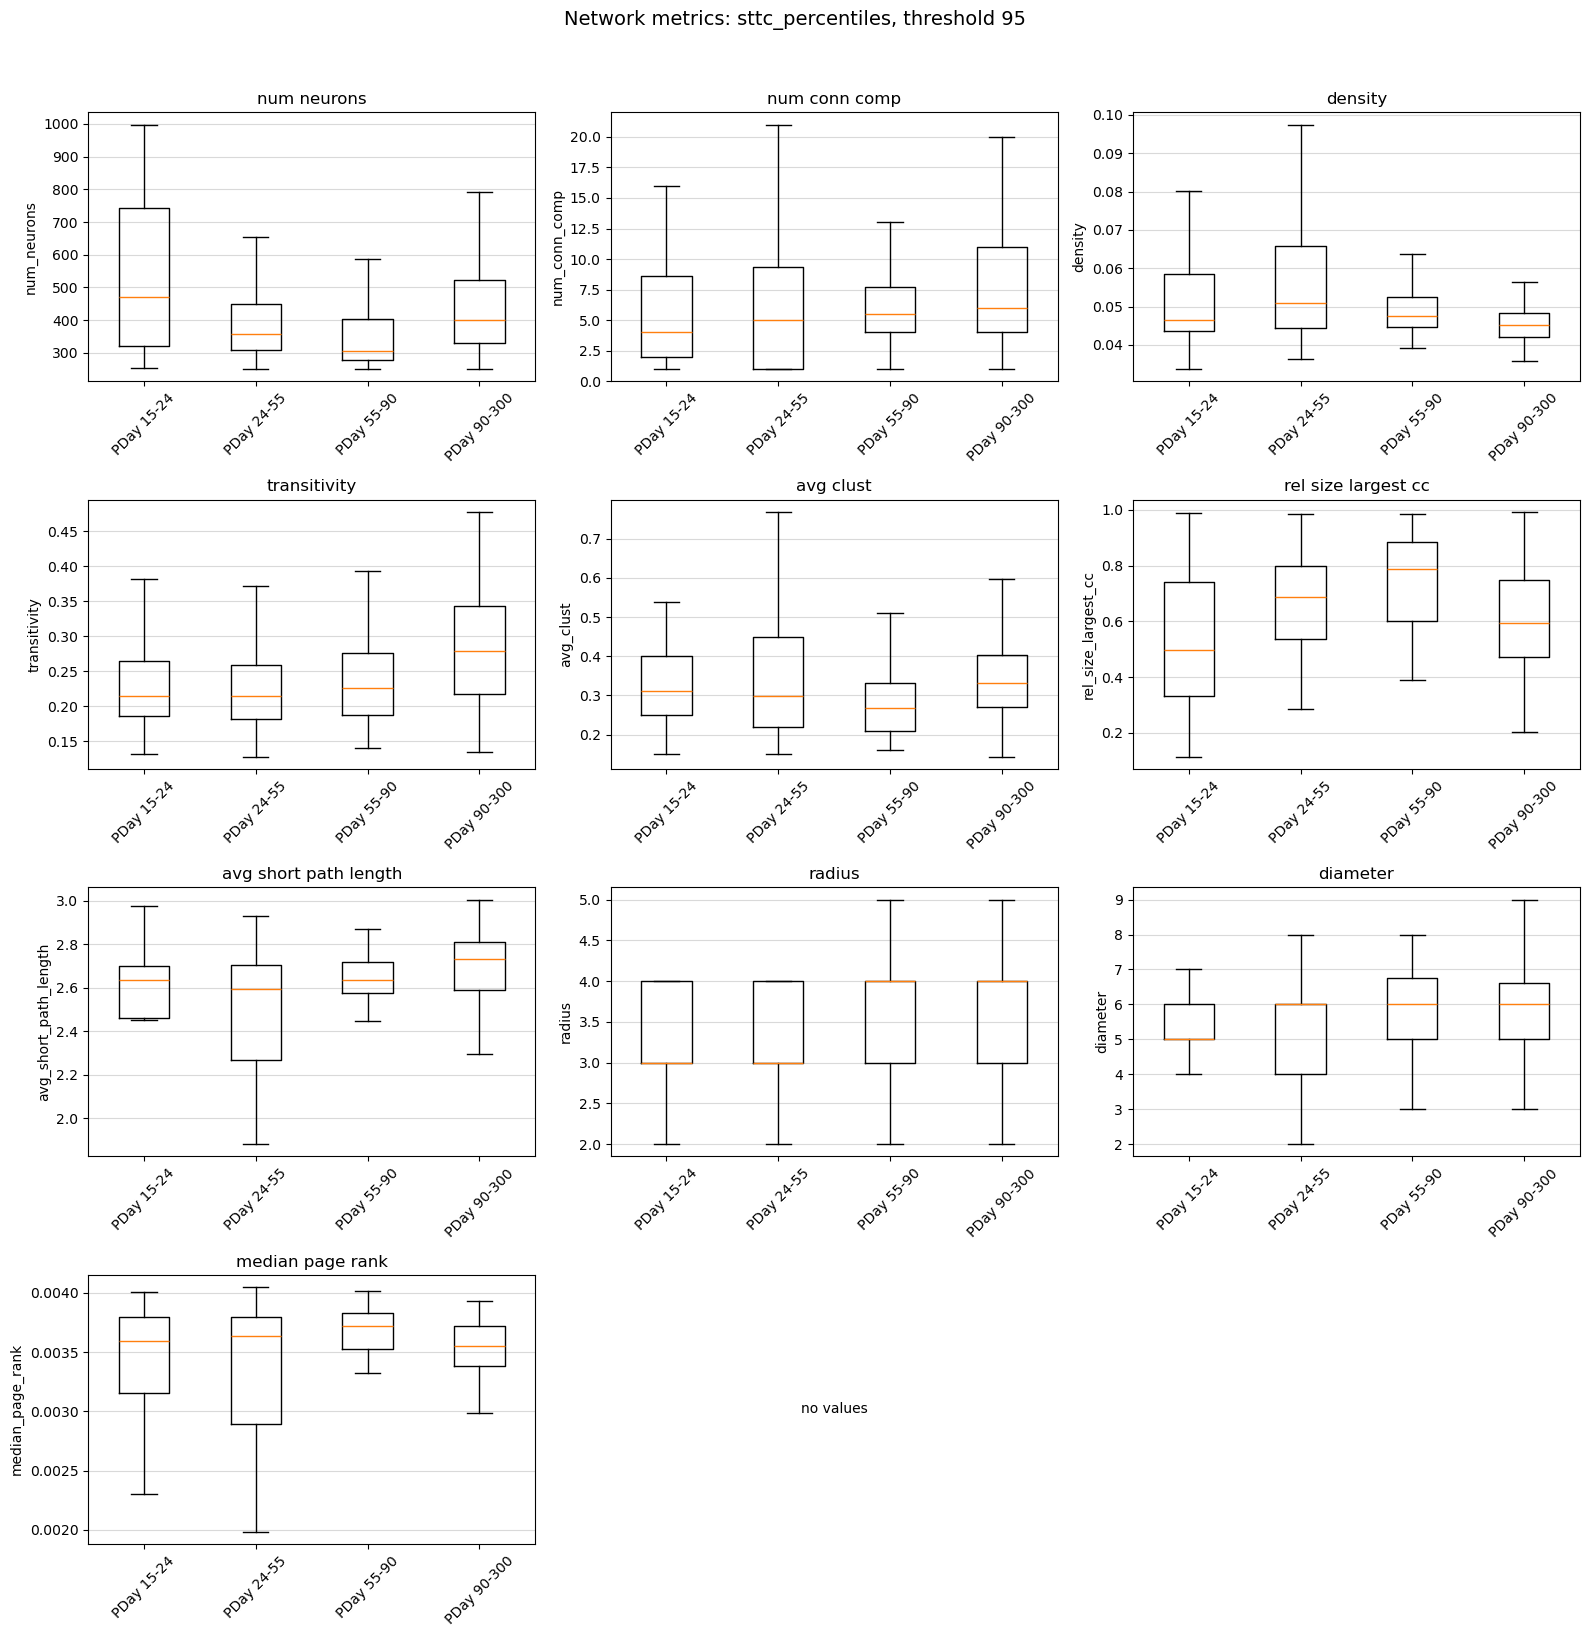

In [10]:
NETWORK_METRICS = [
    "num_neurons",
    "num_conn_comp",
    "density",
    "transitivity",
    "avg_clust",
    "rel_size_largest_cc",
    "avg_short_path_length",
    "radius",
    "diameter",
    "median_page_rank",
    "small_worldness",
]


def plot_network_metric_grid(sim_type, connect_thresh):
    selected = network_df[
        (network_df["sim_type"] == sim_type) & (network_df["connect_thresh"] == connect_thresh)
    ] if not network_df.empty else pd.DataFrame()
    metrics = [metric for metric in NETWORK_METRICS if metric in selected.columns]

    ncols = 3
    nrows = max(1, int(np.ceil(len(metrics) / ncols)))
    fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4 * nrows))
    axes = np.asarray(axes).ravel()

    if selected.empty or not metrics:
        axes[0].text(0.5, 0.5, "missing network summary data", ha="center", va="center")
        axes[0].set_axis_off()
    else:
        for ax, metric in zip(axes, metrics):
            boxplot_by_dev(selected, metric, ax, title=metric.replace("_", " "), ylabel=metric)

    for ax in axes[len(metrics):]:
        ax.set_axis_off()

    fig.suptitle(f"Network metrics: {sim_type}, threshold {connect_thresh}", y=1.02, fontsize=14)
    return fig


for sim_type, connect_thresh in DEFAULT_GRAPH_SPECS:
    fig = plot_network_metric_grid(sim_type, connect_thresh)
    save_summary_fig(fig, f"network_metrics_summary_{sim_type}_{fmt_thresh(connect_thresh)}.png")

Saved F:\Experiments\Steffen\Intrinsic_Imaging\analysis_files\summary_plots\network_threshold_sensitivity_summary.png


WindowsPath('F:/Experiments/Steffen/Intrinsic_Imaging/analysis_files/summary_plots/network_threshold_sensitivity_summary.png')

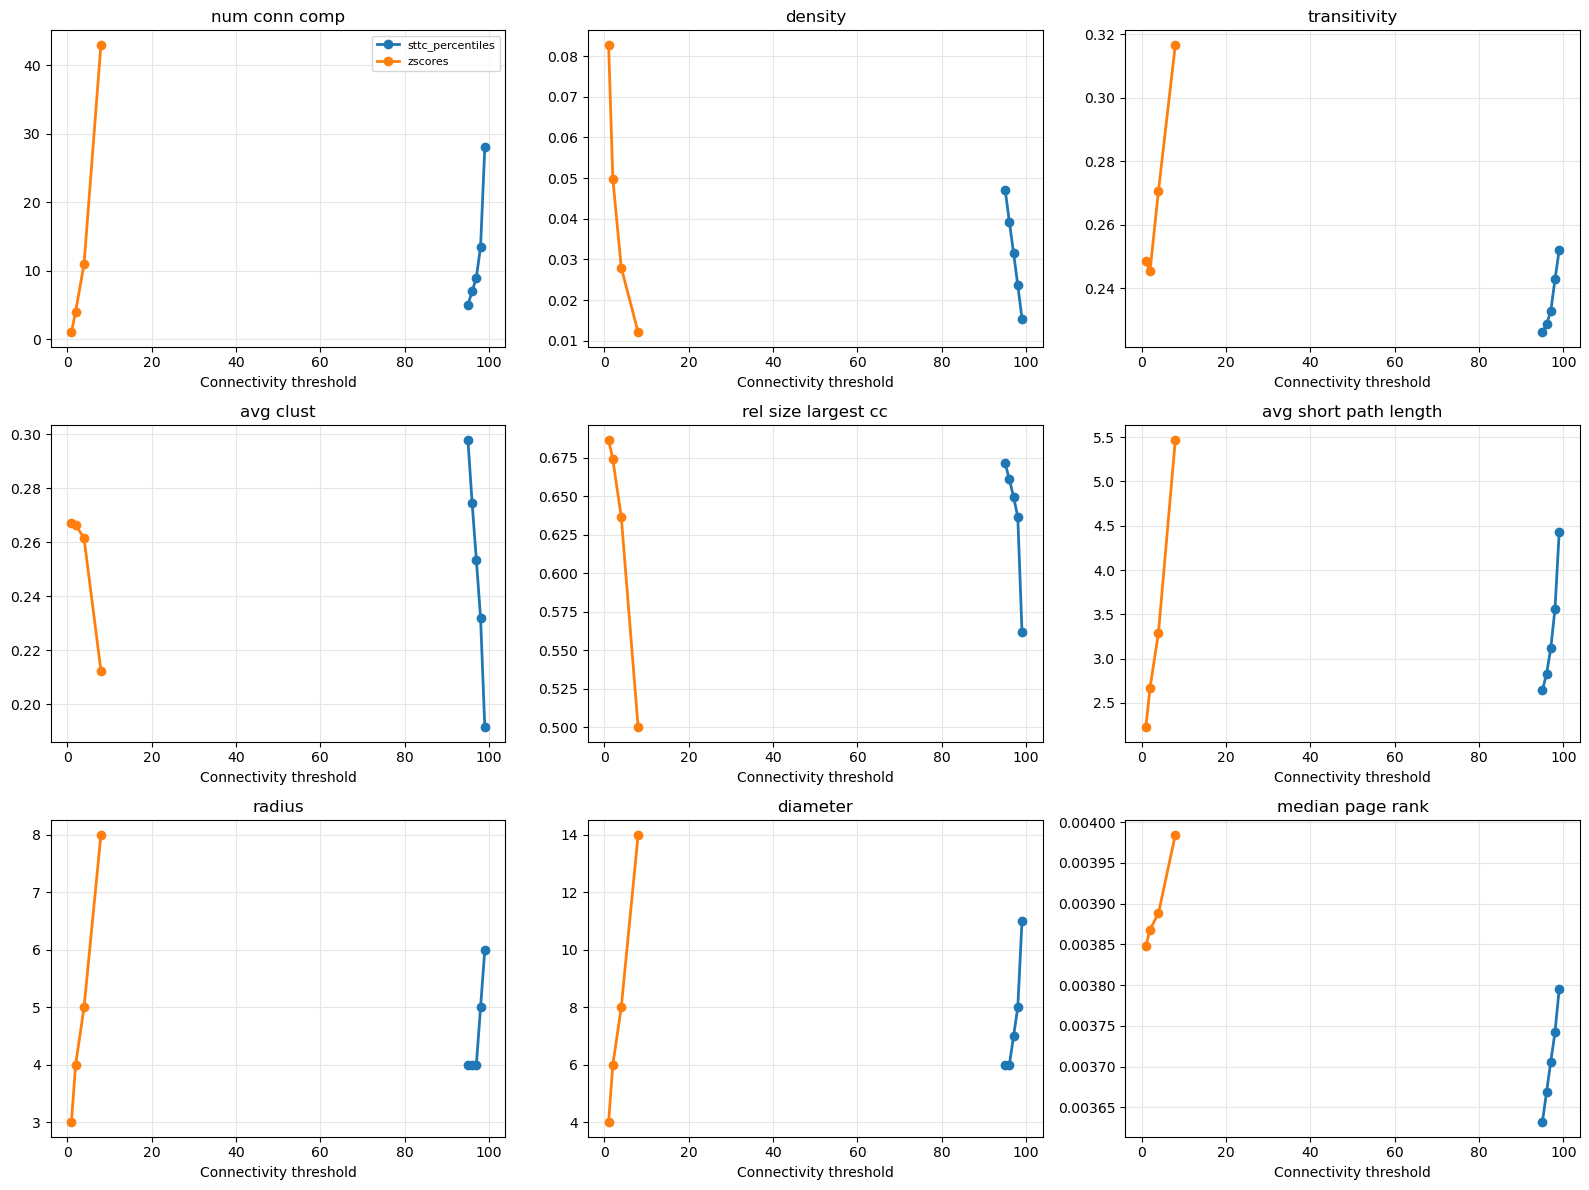

In [11]:
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.ravel()
threshold_metrics = [
    "num_conn_comp",
    "density",
    "transitivity",
    "avg_clust",
    "rel_size_largest_cc",
    "avg_short_path_length",
    "radius",
    "diameter",
    "median_page_rank",
]

if network_df.empty:
    axes[0].text(0.5, 0.5, "missing network summary data", ha="center", va="center")
    axes[0].set_axis_off()
else:
    medians = network_df.groupby(["sim_type", "connect_thresh"], observed=True)[threshold_metrics].median(numeric_only=True)
    for ax, metric in zip(axes, threshold_metrics):
        for sim_type in medians.index.get_level_values("sim_type").unique():
            values = medians.xs(sim_type, level="sim_type")[metric].sort_index()
            ax.plot(values.index, values.values, marker="o", linewidth=2, label=sim_type)
        ax.set_title(metric.replace("_", " "))
        ax.set_xlabel("Connectivity threshold")
        ax.grid(color="0.9")
    axes[0].legend(fontsize=8)

for ax in axes[len(threshold_metrics):]:
    ax.set_axis_off()

save_summary_fig(fig, "network_threshold_sensitivity_summary.png")

## Structural consistency summaries

Saved F:\Experiments\Steffen\Intrinsic_Imaging\analysis_files\summary_plots\structural_consistency_summary.png


C:\Users\mauls\AppData\Local\Temp\ipykernel_56508\641675152.py:70: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(grouped_values, labels=labels, showfliers=showfliers, sym="+")


WindowsPath('F:/Experiments/Steffen/Intrinsic_Imaging/analysis_files/summary_plots/structural_consistency_summary.png')

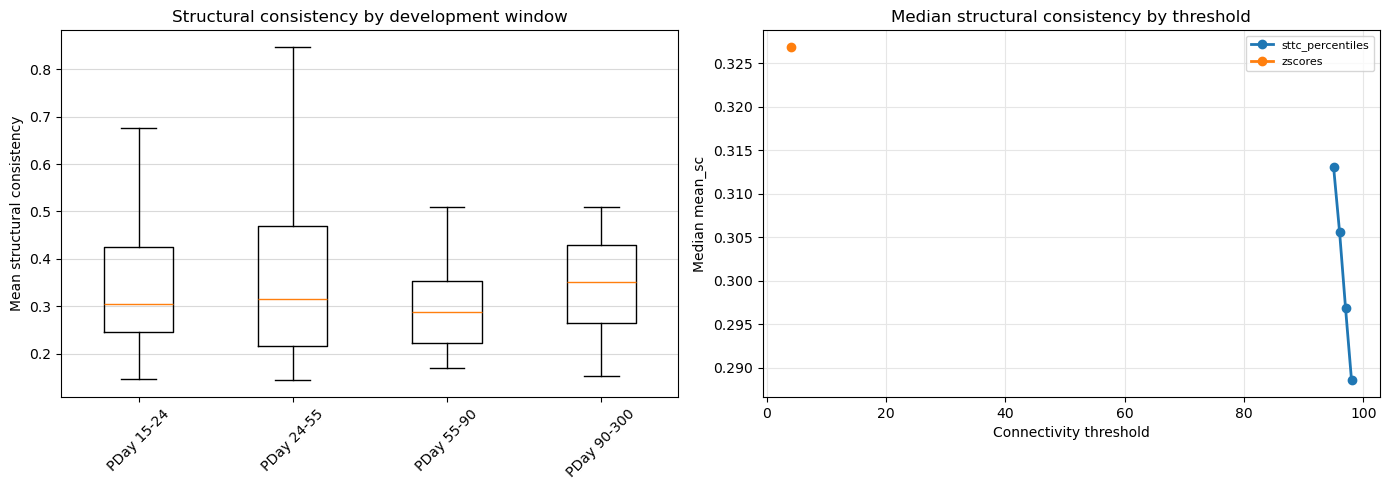

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

if structural_df.empty:
    for ax in axes:
        ax.text(0.5, 0.5, "missing structural consistency data", ha="center", va="center")
        ax.set_axis_off()
else:
    selected = structural_df[
        (structural_df["sim_type"] == "sttc_percentiles") & (structural_df["connect_thresh"] == 95)
    ]
    boxplot_by_dev(
        selected,
        "mean_sc",
        axes[0],
        title="Structural consistency by development window",
        ylabel="Mean structural consistency",
    )

    medians = structural_df.groupby(["sim_type", "connect_thresh"], observed=True)["mean_sc"].median()
    for sim_type in medians.index.get_level_values("sim_type").unique():
        values = medians.xs(sim_type, level="sim_type").sort_index()
        axes[1].plot(values.index, values.values, marker="o", linewidth=2, label=sim_type)
    axes[1].set(title="Median structural consistency by threshold", xlabel="Connectivity threshold", ylabel="Median mean_sc")
    axes[1].grid(color="0.9")
    axes[1].legend(fontsize=8)

save_summary_fig(fig, "structural_consistency_summary.png")

## Laplacian spectra summaries

Saved F:\Experiments\Steffen\Intrinsic_Imaging\analysis_files\summary_plots\laplacian_spectra_summary.png


WindowsPath('F:/Experiments/Steffen/Intrinsic_Imaging/analysis_files/summary_plots/laplacian_spectra_summary.png')

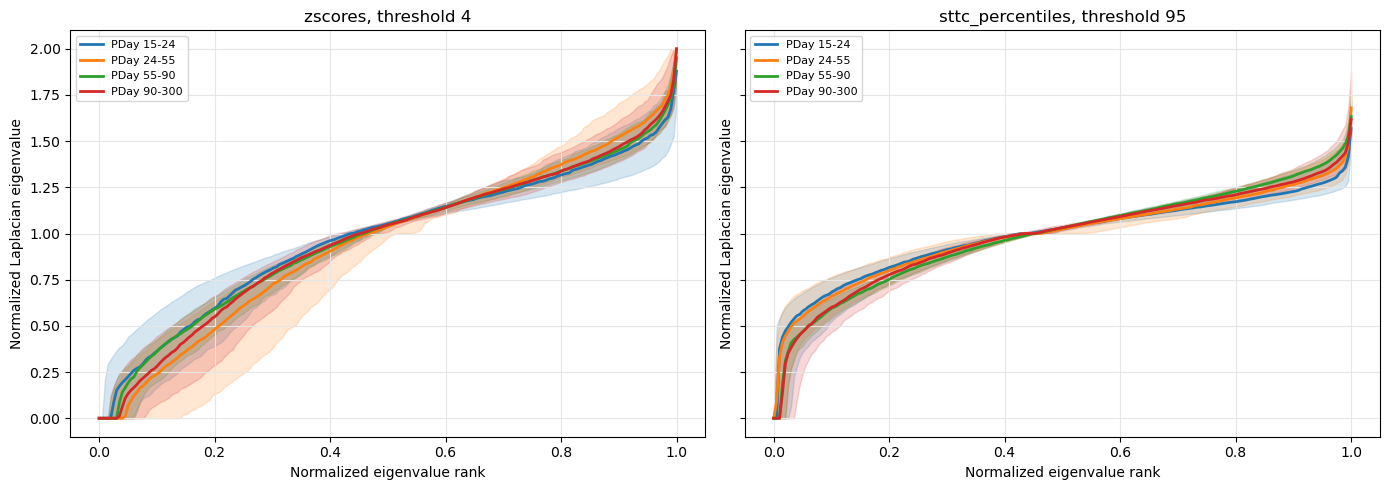

In [13]:
def resample_spectrum(eigenvalues, n_points=200):
    eigenvalues = np.sort(np.asarray(eigenvalues, dtype=float))
    x_old = np.linspace(0.0, 1.0, len(eigenvalues))
    x_new = np.linspace(0.0, 1.0, n_points)
    return x_new, np.interp(x_new, x_old, eigenvalues)


fig, axes = plt.subplots(1, len(DEFAULT_GRAPH_SPECS), figsize=(14, 5), sharey=True)
if len(DEFAULT_GRAPH_SPECS) == 1:
    axes = [axes]

for ax, (sim_type, connect_thresh) in zip(axes, DEFAULT_GRAPH_SPECS):
    selected = laplacian_df[
        (laplacian_df.get("sim_type") == sim_type) & (laplacian_df.get("connect_thresh") == connect_thresh)
    ] if not laplacian_df.empty else pd.DataFrame()

    if selected.empty:
        ax.text(0.5, 0.5, "missing spectra data", ha="center", va="center")
        ax.set_axis_off()
        continue

    for j, label in enumerate(DEV_STAGE_LABELS):
        group = selected[selected["dev_window"] == label]
        if group.empty:
            continue
        curves = []
        x_axis = None
        for eigenvalues in group["eigenvalues"]:
            x_axis, curve = resample_spectrum(eigenvalues)
            curves.append(curve)
        curves = np.vstack(curves)
        median = np.nanmedian(curves, axis=0)
        lower = np.nanpercentile(curves, 25, axis=0)
        upper = np.nanpercentile(curves, 75, axis=0)
        color = plt.cm.tab10(j)
        ax.plot(x_axis, median, color=color, linewidth=2, label=label)
        ax.fill_between(x_axis, lower, upper, color=color, alpha=0.18)

    ax.set_title(f"{sim_type}, threshold {connect_thresh}")
    ax.set_xlabel("Normalized eigenvalue rank")
    ax.set_ylabel("Normalized Laplacian eigenvalue")
    ax.grid(color="0.9")
    ax.legend(fontsize=8)

save_summary_fig(fig, "laplacian_spectra_summary.png")

## Summary index

In [14]:
summary_files = sorted(SUMMARY_PLOT_DIR.glob("*.png"))
summary_index = pd.DataFrame(
    {
        "file": [path.name for path in summary_files],
        "path": [str(path) for path in summary_files],
    }
)
summary_index.to_csv(SUMMARY_PLOT_DIR / "summary_plot_index.csv", index=False)
summary_index

,file,path
0,degree_distribution_summary.png,F:\Experiments\Steffen\Intrinsic_Imaging\analy...
1,laplacian_spectra_summary.png,F:\Experiments\Steffen\Intrinsic_Imaging\analy...
2,network_metrics_summary_sttc_percentiles_95.0.png,F:\Experiments\Steffen\Intrinsic_Imaging\analy...
3,network_metrics_summary_zscores_4.0.png,F:\Experiments\Steffen\Intrinsic_Imaging\analy...
4,network_threshold_sensitivity_summary.png,F:\Experiments\Steffen\Intrinsic_Imaging\analy...
5,similarity_statistics_summary.png,F:\Experiments\Steffen\Intrinsic_Imaging\analy...
6,structural_consistency_summary.png,F:\Experiments\Steffen\Intrinsic_Imaging\analy...
7,trace_statistics_summary.png,F:\Experiments\Steffen\Intrinsic_Imaging\analy...
